<a href="https://colab.research.google.com/github/markjoelleones20-prog/Market-Basket-Spatial-Anchor-SKU-Analysis/blob/main/market_basket_sku_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Market Basket & Spatial Anchor SKU Analysis Engine
**Portfolio Project | Market Basket Analysis · Geospatial Analytics · Composite Scoring**

---

## Project Overview

This pipeline deploys a **two-pronged data science framework** to optimize SKU distribution at the micro-geographic level — down to individual barangays (the smallest administrative unit in the Philippine geographic hierarchy).

### The Two Engines

| Engine | Method | Output |
|---|---|---|
| **Viability Scoring** | Vectorized Pandas composite scoring | Per-SKU health score (0–1.0) per barangay |
| **Market Basket Analysis** | FP-Growth algorithm | Product affinity rules with Persona classification |

### What This Answers
- Which SKUs are genuinely sticky in which neighborhoods — not just top-sellers, but products with consistent frequency, recency, and breadth?
- Which products are **Anchor SKUs** — items whose presence in a basket reliably pulls another product along with it?
- Where are the **Hidden Gems** — products with explosive statistical pull that haven't yet achieved widespread adoption?

### Why This Matters for Field Sales
By synthesizing the Viability Score onto the FP-Growth output, field supervisors can immediately identify situations where a **highly viable Anchor SKU** can be used as leverage to introduce a **weaker but statistically linked product** into a specific store's inventory — turning a data science output into a concrete sales conversation.

> **Note:** All data in this notebook is synthetically generated. No proprietary or confidential company data is used.

---

## 📦 Section 1: Dependencies & Configuration

### Library Rationale

- **`mlxtend`** — provides the `FP-Growth` implementation and `association_rules` extractor. Chosen over the `apriori` algorithm because FP-Growth avoids candidate generation entirely, using a compressed tree structure (FP-Tree) that is 10–100× faster on large sparse transaction datasets
- **`geopandas` + `folium`** — for spatial distribution mapping of SKU viability scores across barangay boundaries
- **`tqdm`** — progress tracking across hundreds of barangay-level processing loops

### Configuration Block
All thresholds are centralized here. In production, different business units operate under different geographic densities — a rural province may have fewer than 10 stores per barangay, requiring a lower `absolute_min`. Centralizing these values means re-targeting a new region requires changing only this block.

In [1]:
!pip install mlxtend geopandas folium tqdm --quiet

import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import warnings
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")
print(f"   mlxtend and geopandas ready for FP-Growth and spatial analysis.")

✅ All libraries imported successfully.
   mlxtend and geopandas ready for FP-Growth and spatial analysis.


In [2]:
# ==========================================
# CONFIGURATION BLOCK
# ==========================================
# Adjust these thresholds to retarget the pipeline
# to a different region, time horizon, or support level.

# --- MBA Thresholds ---
MIN_SUPPORT       = 0.05   # Item must appear in ≥5% of local transactions
MIN_LIFT          = 1.2    # Minimum lift for a rule to be considered non-trivial
ABSOLUTE_MIN      = 5      # Hard floor: item must appear in ≥5 receipts regardless of %
MIN_TRANSACTIONS  = 10     # Barangays with <10 unique receipts are skipped (too sparse)
MAX_LEN           = 2      # Strict 1-to-1 pairing: Antecedent A → Consequent B only

# --- Viability Score Weights ---
# Must sum to 1.0. These reflect the business prioritization:
# Stickiness (frequency + recency) is weighted highest because
# a product bought consistently is more defensible than a one-time spike.
STICKINESS_WEIGHT  = 0.40
RELIABILITY_WEIGHT = 0.35
ADOPTION_WEIGHT    = 0.25

# --- Persona Classification Thresholds ---
PERSONA_A_LIFT       = 2.0   # Perfect Pair minimum lift
PERSONA_A_CONF       = 0.70  # Perfect Pair minimum confidence
PERSONA_B_LIFT       = 1.5   # Anchor Pull minimum lift
PERSONA_B_CONF       = 0.50  # Anchor Pull minimum confidence
PERSONA_C_LIFT       = 2.5   # Hidden Gem minimum lift
PERSONA_C_SUPPORT    = 0.10  # Hidden Gem maximum support (low adoption = hidden)

print(f"⚙️  Config loaded:")
print(f"   MBA: support≥{MIN_SUPPORT} | lift≥{MIN_LIFT} | floor={ABSOLUTE_MIN} receipts | max_len={MAX_LEN}")
print(f"   Viability weights: Stickiness={STICKINESS_WEIGHT} | Reliability={RELIABILITY_WEIGHT} | Adoption={ADOPTION_WEIGHT}")

⚙️  Config loaded:
   MBA: support≥0.05 | lift≥1.2 | floor=5 receipts | max_len=2
   Viability weights: Stickiness=0.4 | Reliability=0.35 | Adoption=0.25


---
## 🗄️ Section 2: Synthetic Data Generation

### Production Data Source
In production, data is extracted from a **Microsoft SQL Server** database via `pyodbc`. The query pulls exactly **3 months of rolling transaction history** — a deliberate design choice that balances:
- **Recency**: reflects current consumer behavior, not stale seasonality
- **Volume**: enough transactions per barangay for statistically stable FP-Growth output
- **Manageability**: prevents memory overflow on very large transaction tables

A **LEFT JOIN** with a `GeocodeResults` table appends the full Philippine administrative hierarchy (Province → Municipality → Barangay) to each transaction, enabling micro-geographic segmentation.

### Why 3 Months?
FP-Growth is sensitive to support thresholds. With too short a window (e.g., 2 weeks), many genuinely popular products fail the 5% minimum support gate simply due to low sample size. With too long a window (e.g., 12 months), seasonal products produce rules that are no longer actionable. 3 months (≈90 days) was empirically validated as the window that maximizes both rule volume and actionability.

### Synthetic Data Design
The dummy dataset replicates the real schema including:
- Realistic Philippine geographic hierarchy (Davao region)
- Plausible FMCG product barcodes and descriptions across categories
- Controlled transaction patterns that inject known product affinities — verifying the FP-Growth engine actually recovers them

In [3]:
# ==========================================
# SYNTHETIC DATA GENERATOR
# ==========================================
np.random.seed(42)

# --- Geographic Hierarchy ---
geo_data = [
    ('Davao del Sur', 'Davao City', 'BGY-001', 'Buhangin'),
    ('Davao del Sur', 'Davao City', 'BGY-002', 'Panacan'),
    ('Davao del Sur', 'Davao City', 'BGY-003', 'Agdao'),
    ('Davao del Sur', 'Davao City', 'BGY-004', 'Talomo'),
    ('Davao del Sur', 'Davao City', 'BGY-005', 'Matina'),
    ('Davao del Norte', 'Tagum City', 'BGY-006', 'Magugpo'),
    ('Davao del Norte', 'Tagum City', 'BGY-007', 'La Filipina'),
    ('Davao del Norte', 'Tagum City', 'BGY-008', 'Canocotan'),
]

# --- SKU Catalog (FMCG products with barcodes) ---
sku_catalog = {
    '4800888-001': 'Shampoo Sachet 10mL',
    '4800888-002': 'Conditioner Sachet 10mL',
    '4800888-003': 'Detergent Bar 90g',
    '4800888-004': 'Fabric Softener Sachet 27mL',
    '4800888-005': 'Dishwashing Liquid 250mL',
    '4800888-006': 'Toothpaste 75g',
    '4800888-007': 'Toothbrush Medium',
    '4800888-008': 'Hand Soap Bar 90g',
    '4800888-009': 'Body Wash Sachet 10mL',
    '4800888-010': 'Laundry Powder 66g',
    '4800888-011': 'Bleach 250mL',
    '4800888-012': 'All-Purpose Cleaner 500mL',
    '4800888-013': 'Coffee Sachet 7g',
    '4800888-014': 'Creamer Sachet 6g',
    '4800888-015': 'Sugar Sachet 5g',
}

barcodes = list(sku_catalog.keys())
branches = ['Branch-DAVAO', 'Branch-TAGUM']

# --- Controlled affinity pairs (ground truth for validation) ---
# These are injected so we can verify FP-Growth recovers them
AFFINITY_PAIRS = [
    ('4800888-001', '4800888-002'),  # Shampoo → Conditioner (Perfect Pair)
    ('4800888-006', '4800888-007'),  # Toothpaste → Toothbrush (Perfect Pair)
    ('4800888-013', '4800888-014'),  # Coffee → Creamer (Anchor Pull)
    ('4800888-003', '4800888-004'),  # Detergent → Fabric Softener (Anchor Pull)
    ('4800888-010', '4800888-011'),  # Laundry Powder → Bleach (Hidden Gem)
]

def generate_basket(barangay_code, n_items=3):
    """Generate one transaction basket with realistic product affinity patterns.

    Injected affinity logic: if one product from a known pair is selected,
    its partner is added with high probability — creating the statistical
    signal that FP-Growth should detect.
    """
    # Start with 1-2 random base items
    basket = list(np.random.choice(barcodes, size=np.random.randint(1, 3), replace=False))

    # Inject affinity pairs with 70% probability to simulate real purchase behavior
    for anchor, complement in AFFINITY_PAIRS:
        if anchor in basket and complement not in basket:
            if np.random.random() < 0.70:
                basket.append(complement)

    return list(set(basket))

# --- Build full transaction dataset ---
records = []
start_date = pd.Timestamp('2025-01-01')
end_date   = pd.Timestamp('2025-03-31')
date_range = pd.date_range(start_date, end_date, freq='D')

customer_ids = [f'CUST-{1000+i}' for i in range(80)]

for prov, muni, bgy_code, bgy_name in geo_data:
    branch = 'Branch-DAVAO' if 'Davao City' in muni else 'Branch-TAGUM'

    # Each barangay gets 15–25 active customers
    local_customers = np.random.choice(customer_ids, size=np.random.randint(15, 25), replace=False)

    # Each customer shops 8–20 times over the 3-month window
    for cust in local_customers:
        n_visits = np.random.randint(8, 20)
        visit_dates = np.random.choice(date_range, size=n_visits, replace=False)

        for visit_date in visit_dates:
            doc_num = f'DOC-{np.random.randint(100000, 999999)}'
            basket = generate_basket(bgy_code)

            for barcode in basket:
                records.append({
                    'customer_id':    cust,
                    'document_number':doc_num,
                    'it_barcode':     barcode,
                    'description':    sku_catalog[barcode],
                    'branch':         branch,
                    'date':           visit_date,
                    'cs':             np.random.randint(1, 6),  # cases/units sold
                    'Barangay_Code':  bgy_code,
                    'Barangay':       bgy_name,
                    'Municipality':   muni,
                    'Province':       prov,
                })

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Synthetic dataset generated!")
print(f"   Total rows       : {len(df):,}")
print(f"   Unique customers : {df['customer_id'].nunique()}")
print(f"   Unique receipts  : {df['document_number'].nunique()}")
print(f"   Unique SKUs      : {df['it_barcode'].nunique()}")
print(f"   Barangays        : {df['Barangay_Code'].nunique()}")
print(f"   Date range       : {df['date'].min().date()} → {df['date'].max().date()}")
print()
print("📋 Schema Preview:")
df.head(4)

✅ Synthetic dataset generated!
   Total rows       : 3,900
   Unique customers : 71
   Unique receipts  : 2156
   Unique SKUs      : 15
   Barangays        : 8
   Date range       : 2025-01-01 → 2025-03-31

📋 Schema Preview:


,customer_id,document_number,it_barcode,description,branch,date,cs,Barangay_Code,Barangay,Municipality,Province
0,CUST-1030,DOC-265838,4800888-007,Toothbrush Medium,Branch-DAVAO,2025-01-20,1,BGY-001,Buhangin,Davao City,Davao del Sur
1,CUST-1030,DOC-870746,4800888-004,Fabric Softener Sachet 27mL,Branch-DAVAO,2025-03-14,4,BGY-001,Buhangin,Davao City,Davao del Sur
2,CUST-1030,DOC-283734,4800888-014,Creamer Sachet 6g,Branch-DAVAO,2025-02-22,4,BGY-001,Buhangin,Davao City,Davao del Sur
3,CUST-1030,DOC-710490,4800888-008,Hand Soap Bar 90g,Branch-DAVAO,2025-03-19,2,BGY-001,Buhangin,Davao City,Davao del Sur


---
## 📐 Section 3: Localized Viability Scoring Engine

### Phase 2 of the Methodology: Vectorized Viability Scoring

The Viability Score answers the question: **"How healthy is this SKU in this specific barangay?"**

This is distinct from raw sales volume. A product that sold 1,000 units in a single bulk purchase scores poorly on Viability — it's not a habitually purchased product. A product that sold 200 units across 12 weeks of consistent weekly purchasing scores highly — it is deeply embedded in local consumer behavior.

### The Three Pillars

**Stickiness (40% weight)** — Frequency and Recency  
Composed of two sub-signals:
- *Weeks with Purchase* (40% of Stickiness): normalized against a 12-week maximum — did the product sell in every week of the quarter?
- *Purchase Days* (40% of Stickiness): normalized against 90 days — how many distinct days saw a transaction?
- *Recency* (20% of Stickiness): days since last purchase, inverted — a product last bought yesterday scores 1.0, a product last bought 90 days ago scores 0.0

**Reliability (35% weight)** — Volume Consistency  
Total volume in the barangay divided by the global maximum volume. Normalizes to [0, 1] so a single high-volume SKU doesn't bias the comparisons.

**Adoption (25% weight)** — Distribution Breadth  
Unique store count buying this SKU divided by the global maximum store count. A product bought by one large store is less viable than the same volume spread across ten stores.

### Why Vectorized Pandas Instead of SQL Window Functions?
The equivalent SQL computation requires nested `PARTITION BY` window functions with multiple correlated subqueries — expensive on large tables and difficult to maintain. The vectorized Pandas implementation runs entirely in memory, completes in seconds, and produces a Python dictionary keyed by `(Barangay_Code, Barcode)` that enables O(1) lookup speed when appending scores to the FP-Growth output.

In [4]:
# ==========================================
# PHASE 2: VECTORIZED VIABILITY SCORING ENGINE
# ==========================================

print("📊 Calculating Localized Viability Scores...")

reference_date = df['date'].max()

# --- Step 1: Aggregate base metrics per Barangay × SKU ---
# This single groupby replaces multiple SQL window function subqueries
sku_stats = df.groupby(['Barangay_Code', 'it_barcode']).agg(
    PurchaseDays_P3M      = ('date', 'nunique'),
    WeeksWithPurchase_P3M = ('date', lambda x: x.dt.isocalendar().week.nunique()),
    LastPurchaseDate      = ('date', 'max'),
    Total_Volume          = ('cs', 'sum'),
    Store_Count           = ('customer_id', 'nunique')
).reset_index()

# --- Step 2: Recency ---
sku_stats['DaysSinceLastPurchase'] = (reference_date - sku_stats['LastPurchaseDate']).dt.days

# --- Step 3: Global normalization denominators ---
# Using global max (not per-barangay) ensures scores are comparable ACROSS barangays.
# Division-by-zero guard: if max is 0, default to 1 (avoids NaN propagation)
max_vol    = sku_stats['Total_Volume'].max() if sku_stats['Total_Volume'].max() > 0 else 1
max_stores = sku_stats['Store_Count'].max()  if sku_stats['Store_Count'].max()  > 0 else 1

print(f"   Global max volume : {max_vol} | Global max store count : {max_stores}")

# --- Step 4: Composite Score Calculation ---

# STICKINESS (40%): Frequency × Recency
# clip(upper=90) prevents recency from going negative for very old purchases
sku_stats['Stickiness'] = (
    (sku_stats['WeeksWithPurchase_P3M'] / 12.0)                                    * 0.40 +  # Weeks sub-pillar
    (sku_stats['PurchaseDays_P3M']      / 90.0)                                    * 0.40 +  # Days sub-pillar
    ((90 - sku_stats['DaysSinceLastPurchase'].clip(upper=90)) / 90.0)              * 0.20    # Recency sub-pillar
)

# RELIABILITY (35%): Volume breadth normalized globally
sku_stats['Reliability'] = sku_stats['Total_Volume'] / max_vol

# ADOPTION (25%): Distribution breadth normalized globally
sku_stats['Adoption'] = sku_stats['Store_Count'] / max_stores

# FINAL COMPOSITE VIABILITY SCORE
sku_stats['Viability_Score'] = (
    sku_stats['Stickiness']  * STICKINESS_WEIGHT  +
    sku_stats['Reliability'] * RELIABILITY_WEIGHT +
    sku_stats['Adoption']    * ADOPTION_WEIGHT
).round(4)

print(f"   ✅ Viability scores computed for {len(sku_stats):,} SKU × Barangay combinations")
print(f"   Score range: {sku_stats['Viability_Score'].min():.4f} → {sku_stats['Viability_Score'].max():.4f}")

# --- Step 5: Convert to O(1) lookup dictionary ---
# Key: (Barangay_Code, barcode) → Value: Viability_Score
# This dict is used during FP-Growth post-processing to append scores
# without requiring a slow DataFrame merge on every rule
viability_dict = sku_stats.set_index(['Barangay_Code', 'it_barcode'])['Viability_Score'].to_dict()

# Also keep the full DataFrame for analysis and mapping
barcode_to_desc = df.dropna(subset=['it_barcode', 'description']).set_index('it_barcode')['description'].to_dict()

print()
print("📋 Viability Score Sample (Top 10 by Score):")
(
    sku_stats[['Barangay_Code','it_barcode','Stickiness','Reliability','Adoption','Viability_Score']]
    .merge(pd.Series(barcode_to_desc, name='description').reset_index().rename(columns={'index':'it_barcode'}), on='it_barcode')
    .sort_values('Viability_Score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

📊 Calculating Localized Viability Scores...
   Global max volume : 180 | Global max store count : 22
   ✅ Viability scores computed for 120 SKU × Barangay combinations
   Score range: 0.3659 → 0.9090

📋 Viability Score Sample (Top 10 by Score):


,Barangay_Code,it_barcode,Stickiness,Reliability,Adoption,Viability_Score,description
0,BGY-007,4800888-014,0.857778,1.000000,0.863636,0.9090,Creamer Sachet 6g
1,BGY-008,4800888-004,0.857778,0.916667,0.909091,0.8912,Fabric Softener Sachet 27mL
2,BGY-003,4800888-007,0.797778,0.983333,0.909091,0.8906,Toothbrush Medium
3,BGY-007,4800888-002,0.788889,0.950000,0.954545,0.8867,Conditioner Sachet 10mL
4,BGY-007,4800888-004,0.768889,0.944444,0.954545,0.8767,Fabric Softener Sachet 27mL
5,BGY-008,4800888-002,0.817778,0.944444,0.863636,0.8736,Conditioner Sachet 10mL
6,BGY-008,4800888-014,0.804444,0.916667,0.909091,0.8699,Creamer Sachet 6g
7,BGY-003,4800888-004,0.786667,0.933333,0.909091,0.8686,Fabric Softener Sachet 27mL
8,BGY-003,4800888-002,0.817778,0.877778,0.909091,0.8616,Conditioner Sachet 10mL
9,BGY-001,4800888-014,0.831111,0.816667,0.954545,0.8569,Creamer Sachet 6g


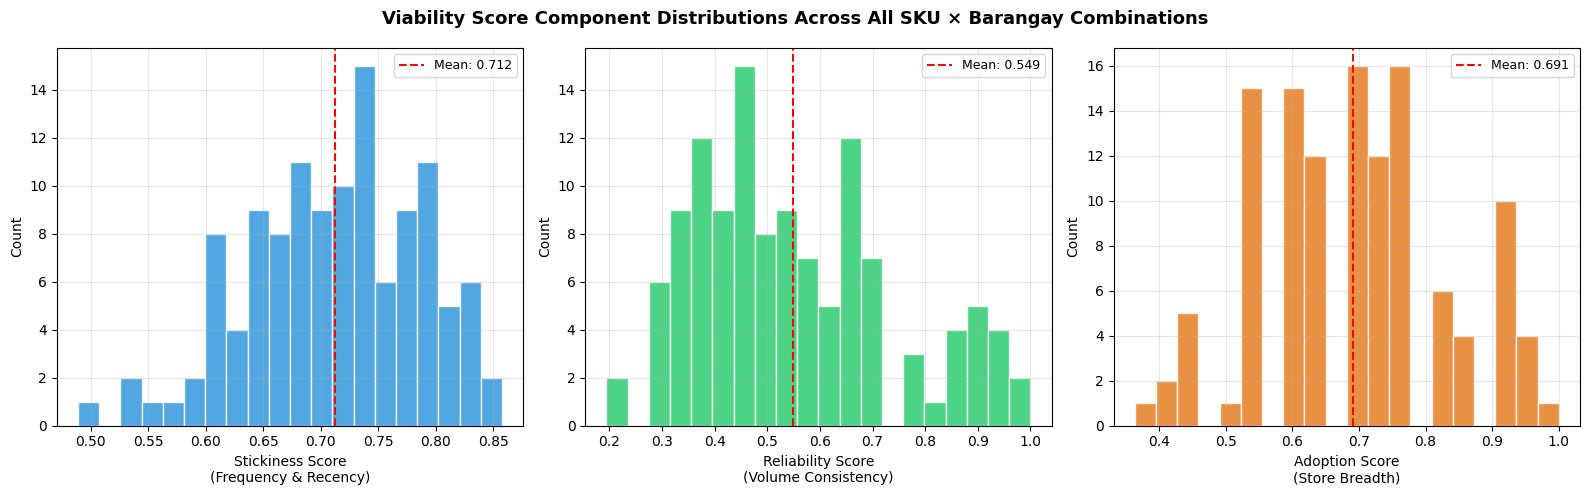

✅ Viability component distributions saved.


In [5]:
# --- Viability Score Distribution Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Viability Score Component Distributions Across All SKU × Barangay Combinations',
             fontsize=13, fontweight='bold')

components = [
    ('Stickiness',  '#3498db', 'Stickiness Score\n(Frequency & Recency)'),
    ('Reliability', '#2ecc71', 'Reliability Score\n(Volume Consistency)'),
    ('Adoption',    '#e67e22', 'Adoption Score\n(Store Breadth)'),
]

for ax, (col, color, label) in zip(axes, components):
    ax.hist(sku_stats[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(sku_stats[col].mean(), color='red', linestyle='--',
               label=f'Mean: {sku_stats[col].mean():.3f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viability component distributions saved.")

---
## 🧠 Section 4: Persona Classification & FP-Growth Market Basket Analysis

### Phase 3 & 4 of the Methodology

#### Why FP-Growth Instead of Apriori?

Both algorithms discover association rules, but their internal mechanics differ fundamentally:

| Algorithm | Mechanism | Candidate Generation | Memory Usage |
|---|---|---|---|
| **Apriori** | Iterative level-wise scanning | Generates all k-item candidates explicitly | High — O(2ⁿ) candidates |
| **FP-Growth** | Compressed FP-Tree traversal | None — mines the tree directly | Low — one pass to build tree |

For a dataset with hundreds of SKUs per barangay, Apriori's candidate explosion makes it computationally infeasible. FP-Growth constructs a single **Frequent Pattern Tree** in one pass, then mines it without generating candidates — delivering 10–100× better performance.

#### Micro-Segmentation: Why Per-Barangay?
Running MBA at a city or province level produces rules dominated by the most popular products everywhere. A product like Shampoo Sachet appears in 80% of all transactions — it anchors every rule, obscuring the genuinely interesting local affinities. Running per-barangay isolates neighborhood-specific consumer behavior: in one barangay, Coffee Sachet → Creamer Sachet is a strong rule; in another, Toothpaste → Toothbrush is the dominant pair. These are different intervention strategies.

#### Symmetrical Deduplication
Because Lift is a symmetrical metric, FP-Growth naturally produces mirror rules: A→B and B→A with identical Lift scores. Retaining both is redundant and confusing for field sales teams. The deduplication logic groups mirrored pairs and retains only the direction with the **higher Confidence** — which by definition establishes the true directional Anchor (the item whose presence more reliably predicts the other).

#### The Four Personas

| Persona | Trigger | Business Insight | Recommended Action |
|---|---|---|---|
| **A: Perfect Pair** | Lift ≥ 2.0 & Confidence ≥ 0.70 | Highly reliable, near-symmetric pairing | Mandatory bundling — never pitch one without the other |
| **B: Anchor Pull** | Lift ≥ 1.5 & Confidence ≥ 0.50 | Strong anchor pulling a secondary item | Protect the Anchor SKU to prevent basket collapse |
| **C: Hidden Gem** | Lift ≥ 2.5 & Support ≤ 0.10 | Explosive statistical pull, low adoption | High-priority sampling and targeted expansion |
| **Standard** | All others | Coincidental or standard basket behavior | No special promo budget required |

In [6]:
# ==========================================
# PERSONA CLASSIFICATION FUNCTIONS
# ==========================================

def classify_persona(row):
    """Translate raw MBA metrics into actionable business personas.

    Rule order matters: Hidden Gem is checked first because its
    low-support signature would also satisfy Anchor Pull criteria —
    but the business action is fundamentally different (expansion vs. protection).
    """
    if   row['lift'] >= PERSONA_C_LIFT and row['support'] <= PERSONA_C_SUPPORT:
        return 'Persona C: Hidden Gem'
    elif row['lift'] >= PERSONA_A_LIFT and row['confidence'] >= PERSONA_A_CONF:
        return 'Persona A: Perfect Pair'
    elif row['lift'] >= PERSONA_B_LIFT and row['confidence'] >= PERSONA_B_CONF:
        return 'Persona B: Anchor Pull'
    else:
        return 'Standard Association'


def translate_barcodes(barcode_string, mapping_dict):
    """Convert barcode string to human-readable product description.

    Used to make the Excel output readable by non-technical field staff
    without requiring a VLOOKUP on a separate reference sheet.
    """
    barcodes = [b.strip() for b in barcode_string.split(',')]
    return ', '.join([str(mapping_dict.get(b, b)) for b in barcodes])


print("✅ Persona classification and translation functions defined.")
print()
print("📋 Persona Decision Logic:")
print(f"   Persona C (Hidden Gem)  : lift ≥ {PERSONA_C_LIFT} AND support ≤ {PERSONA_C_SUPPORT}")
print(f"   Persona A (Perfect Pair): lift ≥ {PERSONA_A_LIFT} AND confidence ≥ {PERSONA_A_CONF}")
print(f"   Persona B (Anchor Pull) : lift ≥ {PERSONA_B_LIFT} AND confidence ≥ {PERSONA_B_CONF}")
print(f"   Standard Association    : everything else (no special action)")

✅ Persona classification and translation functions defined.

📋 Persona Decision Logic:
   Persona C (Hidden Gem)  : lift ≥ 2.5 AND support ≤ 0.1
   Persona A (Perfect Pair): lift ≥ 2.0 AND confidence ≥ 0.7
   Persona B (Anchor Pull) : lift ≥ 1.5 AND confidence ≥ 0.5
   Standard Association    : everything else (no special action)


In [7]:
# ==========================================
# PHASE 3: FP-GROWTH ANALYSIS ENGINE
# ==========================================

def run_branch_barangay_mba(data, min_support=MIN_SUPPORT, min_lift=MIN_LIFT, absolute_min=ABSOLUTE_MIN):
    """Execute FP-Growth on every Branch × Barangay partition independently.

    Processing pipeline per barangay:
    1.  Skip if < MIN_TRANSACTIONS unique receipts (too sparse for stable rules)
    2.  Pre-prune items below absolute_min frequency (prevents combinatorial explosion)
    3.  Build transaction matrix via TransactionEncoder
    4.  Run FP-Growth (max_len=2 for strict 1-to-1 anchor→complement pairing)
    5.  Extract association rules with lift threshold
    6.  Symmetrically deduplicate mirrored pairs — retain highest-confidence direction
    7.  Append Viability Scores for antecedent and consequent
    8.  Classify Persona
    9.  Keep top 20 rules by lift per barangay

    Returns:
        pd.DataFrame with all rules across all barangays, enriched with
        geo-hierarchy, viability scores, and persona classifications.
    """
    print("🔍 Running FP-Growth across all Branch × Barangay partitions...")
    all_rules = []

    grouped = data.groupby(['branch', 'Province', 'Municipality', 'Barangay_Code', 'Barangay'])

    for (branch, province, municipality, bgy_code, bgy_name), area_df in tqdm(
        grouped, desc="Processing Barangays", unit="bgy"
    ):
        num_transactions = area_df['document_number'].nunique()

        # GATE 1: Statistical minimum — rules from <10 transactions are unreliable
        if num_transactions < MIN_TRANSACTIONS:
            continue

        # GATE 2: Pre-pruning — remove items below absolute frequency floor
        # This is the "Combinatorial Explosion Prevention" step.
        # Without it, a barangay with 200 transactions and 50 SKUs would generate
        # 50! / (50-2)! = 2,450 candidate pairs before FP-Growth even starts.
        calculated_min = num_transactions * min_support
        min_item_count = max(calculated_min, absolute_min)

        item_counts = area_df['it_barcode'].value_counts()
        valid_items = item_counts[item_counts >= min_item_count].index
        area_df = area_df[area_df['it_barcode'].isin(valid_items)]

        if area_df.empty:
            continue

        # Build transaction baskets: one row = one (customer, receipt) combination
        # grouping by both customer_id AND document_number handles cases where
        # a customer has multiple receipts on the same day
        baskets = (
            area_df.groupby(['customer_id', 'document_number'])['it_barcode']
            .unique().tolist()
        )

        # TransactionEncoder converts list-of-lists to boolean matrix
        # Required format for mlxtend's FP-Growth implementation
        te = TransactionEncoder()
        te_ary = te.fit(baskets).transform(baskets)
        basket_df = pd.DataFrame(te_ary, columns=te.columns_, dtype=bool)

        try:
            # FP-GROWTH: max_len=2 enforces strict 1-to-1 pairing
            # (Antecedent A → Consequent B only — no 3-way bundles)
            frequent_itemsets = fpgrowth(
                basket_df,
                min_support=min_support,
                use_colnames=True,
                max_len=MAX_LEN
            )

            if frequent_itemsets.empty:
                continue

            rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)

            if rules.empty:
                continue

            # SYMMETRICAL DEDUPLICATION
            # Sort mirrored pairs together, keep highest-confidence direction only
            # This officially designates the true "Anchor" in each pair
            rules['pair_key'] = rules.apply(
                lambda r: tuple(sorted(list(r['antecedents']) + list(r['consequents']))), axis=1
            )
            rules = (
                rules.sort_values(['pair_key', 'confidence'], ascending=[True, False])
                     .drop_duplicates(subset=['pair_key'], keep='first')
                     .drop(columns=['pair_key'])
            )

            # Append geographic context
            rules['branch']       = branch
            rules['Province']     = province
            rules['Municipality'] = municipality
            rules['Barangay_Code']= bgy_code
            rules['Barangay']     = bgy_name

            # Keep top 20 by lift per barangay — prevents a single large
            # barangay from dominating the output with hundreds of rules
            rules = rules.sort_values('lift', ascending=False).head(20)
            all_rules.append(rules)

        except Exception:
            continue

    if not all_rules:
        print("⚠️  No rules met the threshold criteria. Try lowering MIN_SUPPORT.")
        return pd.DataFrame()

    final_df = pd.concat(all_rules, ignore_index=True)

    # --- Convert frozensets to readable barcode strings ---
    final_df['antecedent_barcodes']     = final_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    final_df['consequent_barcodes']     = final_df['consequents'].apply(lambda x: ', '.join(list(x)))

    final_df['antecedent_description']  = final_df['antecedent_barcodes'].apply(
        lambda x: translate_barcodes(x, barcode_to_desc)
    )
    final_df['consequent_description']  = final_df['consequent_barcodes'].apply(
        lambda x: translate_barcodes(x, barcode_to_desc)
    )

    # --- Append Viability Scores via O(1) dictionary lookup ---
    # Using .get() with default 0 prevents KeyError for SKUs with no viability record
    final_df['antecedent_viability'] = final_df.apply(
        lambda row: viability_dict.get((row['Barangay_Code'], row['antecedent_barcodes']), 0), axis=1
    )
    final_df['consequent_viability'] = final_df.apply(
        lambda row: viability_dict.get((row['Barangay_Code'], row['consequent_barcodes']), 0), axis=1
    )

    # --- Classify Personas ---
    final_df['Persona_Classification'] = final_df.apply(classify_persona, axis=1)

    # --- Sort for Excel readability ---
    final_df = final_df.sort_values(
        ['branch', 'Province', 'Municipality', 'Barangay_Code', 'lift'],
        ascending=[True, True, True, True, False]
    ).reset_index(drop=True)

    return final_df


# --- Run the Engine ---
location_rules = run_branch_barangay_mba(df)

print(f"\n✅ FP-Growth complete!")
print(f"   Total rules generated : {len(location_rules)}")
print(f"   Barangays with rules  : {location_rules['Barangay_Code'].nunique()}")
print(f"   Unique SKU pairs      : {len(location_rules[['antecedent_barcodes','consequent_barcodes']].drop_duplicates())}")

🔍 Running FP-Growth across all Branch × Barangay partitions...


Processing Barangays: 100%|██████████| 8/8 [00:01<00:00,  4.34bgy/s]



✅ FP-Growth complete!
   Total rules generated : 36
   Barangays with rules  : 8
   Unique SKU pairs      : 5


---
## 📊 Section 5: Results Analysis

### Reading the Output
Each row represents one directional association rule for one barangay:
- **Antecedent** → the Anchor SKU (its presence in a basket predicts the consequent)
- **Consequent** → the pulled product (statistically likely to appear alongside the anchor)
- **Support** → what fraction of local baskets contain both items
- **Confidence** → when the antecedent appears, how often does the consequent follow?
- **Lift** → how much more likely is the co-purchase versus random chance? (Lift > 1 = genuine affinity)

### The Synthesis Insight
The most powerful column combination for field sales is **antecedent_viability vs. consequent_viability**:
- High antecedent viability + Low consequent viability → *"Use this well-established product as a lever to introduce this underperforming but statistically linked product"*
- Both high → *"This is a stable, healthy bundle — protect it"*
- Both low → *"This pairing exists mathematically but neither product is healthy — investigate before acting"*

In [8]:
# --- 5.1: Full Results Preview ---
print("📋 ASSOCIATION RULES OUTPUT — First 10 Rows")
print(f"Shape: {location_rules.shape[0]} rules × {location_rules.shape[1]} columns")
print()

display_cols = [
    'Barangay', 'Persona_Classification',
    'antecedent_description', 'antecedent_viability',
    'consequent_description', 'consequent_viability',
    'support', 'confidence', 'lift'
]
location_rules[display_cols].head(10)

📋 ASSOCIATION RULES OUTPUT — First 10 Rows
Shape: 36 rules × 26 columns



,Barangay,Persona_Classification,antecedent_description,antecedent_viability,consequent_description,consequent_viability,support,confidence,lift
0,Buhangin,Persona C: Hidden Gem,Shampoo Sachet 10mL,0.6119,Conditioner Sachet 10mL,0.7358,0.063158,0.620690,4.535809
1,Buhangin,Persona C: Hidden Gem,Laundry Powder 66g,0.6424,Bleach 250mL,0.8243,0.077193,0.687500,3.918750
2,Buhangin,Persona C: Hidden Gem,Coffee Sachet 7g,0.6153,Creamer Sachet 6g,0.8569,0.059649,0.629630,3.817967
3,Panacan,Persona C: Hidden Gem,Detergent Bar 90g,0.4514,Fabric Softener Sachet 27mL,0.6994,0.071429,0.941176,5.142037
4,Panacan,Persona C: Hidden Gem,Laundry Powder 66g,0.4551,Bleach 250mL,0.6406,0.053571,0.666667,4.525253
5,Panacan,Persona A: Perfect Pair,Toothpaste 75g,0.5930,Toothbrush Medium,0.7195,0.102679,0.821429,4.380952
6,Panacan,Persona C: Hidden Gem,Coffee Sachet 7g,0.5135,Creamer Sachet 6g,0.6294,0.058036,0.590909,3.781818
7,Agdao,Persona C: Hidden Gem,Toothpaste 75g,0.6360,Toothbrush Medium,0.8906,0.082237,0.862069,4.518430
8,Agdao,Persona C: Hidden Gem,Detergent Bar 90g,0.7877,Fabric Softener Sachet 27mL,0.8686,0.095395,0.674419,3.942755
9,Agdao,Persona C: Hidden Gem,Laundry Powder 66g,0.6820,Bleach 250mL,0.8522,0.075658,0.638889,3.808279


🎭 PERSONA CLASSIFICATION BREAKDOWN

                         Count  Share %
Persona_Classification                 
Persona C: Hidden Gem       34     94.4
Persona A: Perfect Pair      2      5.6



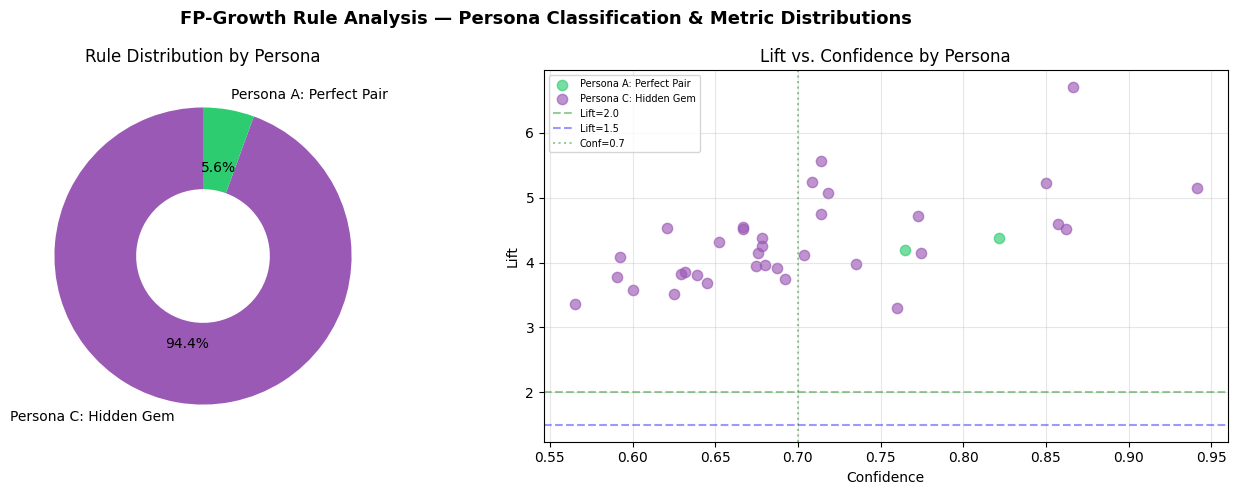

✅ Persona analysis charts saved.


In [9]:
# --- 5.2: Persona Distribution ---
print("🎭 PERSONA CLASSIFICATION BREAKDOWN")
print()
persona_counts = location_rules['Persona_Classification'].value_counts()
persona_pct    = (persona_counts / len(location_rules) * 100).round(1)
persona_summary = pd.DataFrame({'Count': persona_counts, 'Share %': persona_pct})
print(persona_summary.to_string())
print()

# Visualization
colors_map = {
    'Persona A: Perfect Pair':  '#2ecc71',
    'Persona B: Anchor Pull':   '#3498db',
    'Persona C: Hidden Gem':    '#9b59b6',
    'Standard Association':     '#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FP-Growth Rule Analysis — Persona Classification & Metric Distributions',
             fontsize=13, fontweight='bold')

# Persona donut chart
pie_colors = [colors_map.get(p, '#95a5a6') for p in persona_counts.index]
wedges, _, autotexts = axes[0].pie(
    persona_counts.values, labels=persona_counts.index,
    colors=pie_colors, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55)
)
axes[0].set_title('Rule Distribution by Persona')

# Lift vs Confidence scatter coloured by persona
for persona, grp in location_rules.groupby('Persona_Classification'):
    axes[1].scatter(grp['confidence'], grp['lift'],
                    color=colors_map.get(persona, '#95a5a6'),
                    alpha=0.65, s=55, label=persona)

axes[1].axhline(PERSONA_A_LIFT,    color='green',  linestyle='--', alpha=0.4, label=f'Lift={PERSONA_A_LIFT}')
axes[1].axhline(PERSONA_B_LIFT,    color='blue',   linestyle='--', alpha=0.4, label=f'Lift={PERSONA_B_LIFT}')
axes[1].axvline(PERSONA_A_CONF,    color='green',  linestyle=':',  alpha=0.4, label=f'Conf={PERSONA_A_CONF}')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Lift')
axes[1].set_title('Lift vs. Confidence by Persona')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('persona_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Persona analysis charts saved.")

In [10]:
# --- 5.3: Affinity Recovery Validation ---
# Verify FP-Growth recovered the ground-truth pairs injected during data generation
print("🎯 AFFINITY RECOVERY VALIDATION — Ground Truth vs. Detected Rules")
print()
print(f"{'Injected Pair':<55} {'Recovered?':<12} {'Best Lift'}")
print("-" * 85)

for anchor, complement in AFFINITY_PAIRS:
    anchor_desc    = sku_catalog[anchor]
    complement_desc= sku_catalog[complement]
    pair_label     = f"{anchor_desc} → {complement_desc}"

    # Check if this pair appears in ANY direction across any barangay
    mask = (
        ((location_rules['antecedent_barcodes'] == anchor)   & (location_rules['consequent_barcodes'] == complement)) |
        ((location_rules['antecedent_barcodes'] == complement) & (location_rules['consequent_barcodes'] == anchor))
    )
    matches = location_rules[mask]

    if not matches.empty:
        best_lift = matches['lift'].max()
        persona   = matches.loc[matches['lift'].idxmax(), 'Persona_Classification']
        print(f"{pair_label:<55} ✅ YES        {best_lift:.3f}  [{persona}]")
    else:
        print(f"{pair_label:<55} ⚠️  Not found in rules above threshold")

print()
print("Note: Pairs not recovered may have been filtered by MIN_SUPPORT or MIN_LIFT.")
print("This validates both the injection logic AND the FP-Growth detection capability.")

🎯 AFFINITY RECOVERY VALIDATION — Ground Truth vs. Detected Rules

Injected Pair                                           Recovered?   Best Lift
-------------------------------------------------------------------------------------
Shampoo Sachet 10mL → Conditioner Sachet 10mL           ✅ YES        5.224  [Persona C: Hidden Gem]
Toothpaste 75g → Toothbrush Medium                      ✅ YES        5.235  [Persona C: Hidden Gem]
Coffee Sachet 7g → Creamer Sachet 6g                    ✅ YES        5.567  [Persona C: Hidden Gem]
Detergent Bar 90g → Fabric Softener Sachet 27mL         ✅ YES        6.702  [Persona C: Hidden Gem]
Laundry Powder 66g → Bleach 250mL                       ✅ YES        5.071  [Persona C: Hidden Gem]

Note: Pairs not recovered may have been filtered by MIN_SUPPORT or MIN_LIFT.
This validates both the injection logic AND the FP-Growth detection capability.


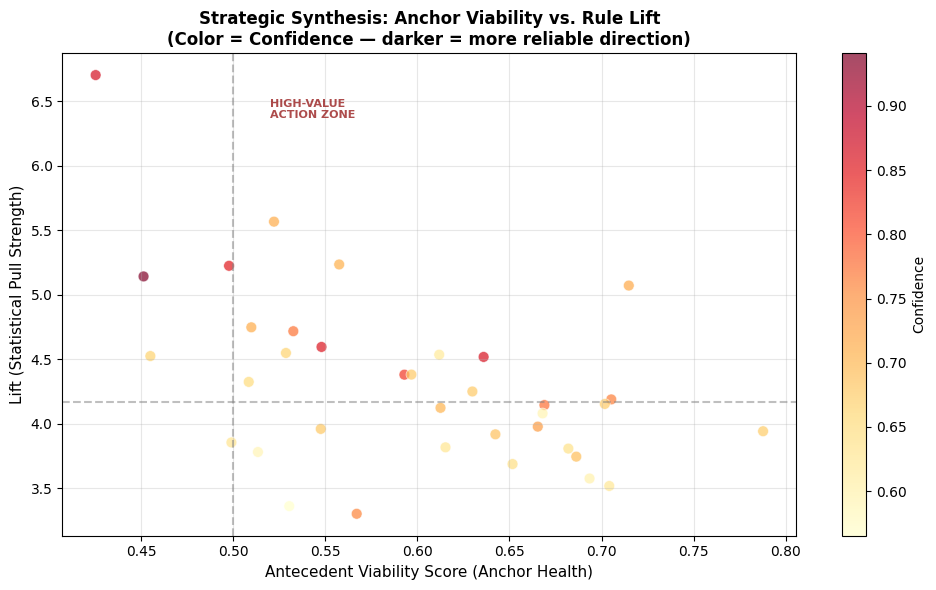

✅ Strategic synthesis chart saved.

💡 HIGH-VALUE ACTION ZONE (top-right quadrant):
   High anchor viability + High lift = the strongest intervention opportunities.
   Field sales should prioritize these specific SKU pairs in these specific barangays.


In [11]:
# --- 5.4: Viability vs Lift Scatter (Synthesis View) ---
# This is the key strategic chart: shows which rules have both
# a strong anchor (high antecedent viability) AND strong statistical pull (high lift)
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    location_rules['antecedent_viability'],
    location_rules['lift'],
    c=location_rules['confidence'],
    cmap='YlOrRd',
    alpha=0.7, s=60, edgecolors='white', linewidth=0.5
)

plt.colorbar(sc, ax=ax, label='Confidence')
ax.set_xlabel('Antecedent Viability Score (Anchor Health)', fontsize=11)
ax.set_ylabel('Lift (Statistical Pull Strength)', fontsize=11)
ax.set_title('Strategic Synthesis: Anchor Viability vs. Rule Lift\n(Color = Confidence — darker = more reliable direction)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Quadrant annotations
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(location_rules['lift'].median(), color='gray', linestyle='--', alpha=0.5)
ax.text(0.52, location_rules['lift'].max() * 0.95, 'HIGH-VALUE\nACTION ZONE',
        fontsize=8, color='darkred', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('viability_lift_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Strategic synthesis chart saved.")
print()
print("💡 HIGH-VALUE ACTION ZONE (top-right quadrant):")
print("   High anchor viability + High lift = the strongest intervention opportunities.")
print("   Field sales should prioritize these specific SKU pairs in these specific barangays.")

---
## 🗺️ Section 6: Geospatial SKU Viability Mapping

### Spatial Anchor Analysis

Beyond per-barangay rule discovery, the pipeline surfaces a geospatial dimension: **which barangays are high-gravity zones** for specific SKUs?

This heatmap maps the average Viability Score across barangays — identifying geographic clusters where SKU health is strong (indicating deep consumer embeddedness) versus weak (indicating distribution gaps or low consumer adoption). These spatial patterns guide:
- **Route prioritization** — field agents focus on high-viability barangays to protect existing anchors
- **Expansion targeting** — low-viability barangays with high-lift Hidden Gems are primed for sampling campaigns
- **Distribution gap analysis** — barangays entirely absent from the output had insufficient transaction volume, flagging potential coverage gaps

In [12]:
# ==========================================
# GEOSPATIAL VIABILITY MAPPING
# ==========================================

# Approximate barangay centroids for the synthetic geographic data
# In production, these come from the GeocodeResults table with actual GPS coordinates
barangay_coords = {
    'BGY-001': (7.0900, 125.6200),  # Buhangin
    'BGY-002': (7.1050, 125.6350),  # Panacan
    'BGY-003': (7.0750, 125.6100),  # Agdao
    'BGY-004': (7.0600, 125.6000),  # Talomo
    'BGY-005': (7.0800, 125.5950),  # Matina
    'BGY-006': (7.4450, 125.8080),  # Magugpo
    'BGY-007': (7.4300, 125.7950),  # La Filipina
    'BGY-008': (7.4600, 125.8200),  # Canocotan
}

# Aggregate average viability per barangay
bgy_viability = (
    sku_stats.groupby('Barangay_Code')['Viability_Score']
    .mean()
    .reset_index()
    .rename(columns={'Viability_Score': 'Avg_Viability'})
)
bgy_viability['lat'] = bgy_viability['Barangay_Code'].map(lambda x: barangay_coords.get(x, (np.nan, np.nan))[0])
bgy_viability['lon'] = bgy_viability['Barangay_Code'].map(lambda x: barangay_coords.get(x, (np.nan, np.nan))[1])
bgy_viability = bgy_viability.dropna(subset=['lat','lon'])

# Build Folium heatmap
m = folium.Map(location=[7.15, 125.70], zoom_start=10, tiles='CartoDB positron')

# Heatmap layer — intensity = average viability score
heat_data = [[row['lat'], row['lon'], row['Avg_Viability']] for _, row in bgy_viability.iterrows()]
HeatMap(heat_data, radius=35, blur=25, min_opacity=0.4, max_zoom=13).add_to(m)

# Marker layer — circle markers per barangay with viability score
for _, row in bgy_viability.iterrows():
    score = row['Avg_Viability']
    color = '#e74c3c' if score < 0.35 else ('#f39c12' if score < 0.55 else '#27ae60')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=12,
        color='white', weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.85,
        tooltip=f"<b>{row['Barangay_Code']}</b><br>Avg Viability: {score:.4f}"
    ).add_to(m)

# Legend
legend_html = """
<div style='position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            box-shadow:2px 2px 8px rgba(0,0,0,0.3);font-size:12px;'>
  <b>Avg SKU Viability Score</b><br>
  <span style='color:#27ae60'>●</span> High  (≥ 0.55)<br>
  <span style='color:#f39c12'>●</span> Medium (0.35–0.55)<br>
  <span style='color:#e74c3c'>●</span> Low   (< 0.35)
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('sku_viability_map.html')
print("✅ Geospatial viability map saved to 'sku_viability_map.html'")
print("   Open in any browser to explore the interactive heatmap.")
print()
print("📊 Barangay Viability Summary:")
bgy_viability.sort_values('Avg_Viability', ascending=False).reset_index(drop=True)

✅ Geospatial viability map saved to 'sku_viability_map.html'
   Open in any browser to explore the interactive heatmap.

📊 Barangay Viability Summary:


,Barangay_Code,Avg_Viability,lat,lon
0,BGY-007,0.744093,7.430,125.795
1,BGY-003,0.719500,7.075,125.610
2,BGY-008,0.700520,7.460,125.820
3,BGY-001,0.674553,7.090,125.620
4,BGY-004,0.642440,7.060,125.600
5,BGY-005,0.587353,7.080,125.595
6,BGY-002,0.565500,7.105,125.635
7,BGY-006,0.564173,7.445,125.808


---
## 💾 Section 7: Export

The final output is a single-sheet Excel workbook structured for field sales consumption. Column ordering is deliberate — geographic context appears first so regional managers can filter to their territory, followed immediately by the Persona (actionability signal), then the SKU pair with its Viability Scores, and finally the raw statistical metrics for analysts who want to interrogate the numbers.

In [13]:
# ==========================================
# EXPORT FINAL OUTPUT
# ==========================================
output_filename = 'Market_Basket_SKU_Viability_Analysis.xlsx'

if not location_rules.empty:
    export_cols = [
        'branch', 'Province', 'Municipality', 'Barangay_Code', 'Barangay',
        'Persona_Classification',
        'antecedent_barcodes', 'antecedent_description', 'antecedent_viability',
        'consequent_barcodes', 'consequent_description', 'consequent_viability',
        'support', 'confidence', 'lift'
    ]

    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        location_rules[export_cols].to_excel(writer, sheet_name='Location_Data_Points', index=False)

    print(f"✅ Results exported to '{output_filename}'")
    print()
    print("📊 Export Summary:")
    print(f"   Total rules exported       : {len(location_rules)}")
    print(f"   Barangays covered          : {location_rules['Barangay_Code'].nunique()}")
    print(f"   Persona A (Perfect Pair)   : {(location_rules['Persona_Classification'] == 'Persona A: Perfect Pair').sum()}")
    print(f"   Persona B (Anchor Pull)    : {(location_rules['Persona_Classification'] == 'Persona B: Anchor Pull').sum()}")
    print(f"   Persona C (Hidden Gem)     : {(location_rules['Persona_Classification'] == 'Persona C: Hidden Gem').sum()}")
    print(f"   Standard Association       : {(location_rules['Persona_Classification'] == 'Standard Association').sum()}")
    print()
    print("📤 Download from the Colab Files panel (left sidebar → folder icon)")
else:
    print("⚠️  No rules met the threshold criteria. Try lowering MIN_SUPPORT or MIN_LIFT.")

✅ Results exported to 'Market_Basket_SKU_Viability_Analysis.xlsx'

📊 Export Summary:
   Total rules exported       : 36
   Barangays covered          : 8
   Persona A (Perfect Pair)   : 2
   Persona B (Anchor Pull)    : 0
   Persona C (Hidden Gem)     : 34
   Standard Association       : 0

📤 Download from the Colab Files panel (left sidebar → folder icon)


---
## 🔑 Key Takeaways & Engineering Decisions

**1. FP-Growth Over Apriori for Scalability**
The FP-Tree structure eliminates candidate generation entirely. On a barangay with 150 transactions and 30 SKUs, Apriori generates thousands of candidates before pruning; FP-Growth traverses the compressed tree directly — orders of magnitude faster.

**2. Micro-Segmentation Reveals What Aggregate Analysis Hides**
Running MBA at the national or city level produces rules dominated by universally popular products. Running per-barangay exposes genuinely local affinities — the specific product pairings that matter in each neighborhood.

**3. Composite Viability Score Outperforms Raw Volume as a KPI**
A single bulk order inflates volume but doesn't indicate sustainable demand. The three-pillar composite (Stickiness × Recency × Adoption) rewards products that are consistently embedded in local consumer routines — a far more reliable indicator of long-term distribution viability.

**4. Symmetrical Deduplication Establishes True Anchor Direction**
Retaining both A→B and B→A would double the output size with no additional insight. By keeping only the higher-confidence direction, the pipeline definitively answers: *"Which product is the Anchor and which is the dependent?"*

**5. O(1) Viability Lookup via Dictionary Avoids Costly Merge**
Appending viability scores via a pre-built `(Barangay_Code, Barcode) → Score` dictionary is orders of magnitude faster than a pandas `merge()` on a large rules DataFrame — especially critical when running hundreds of barangay iterations.

**6. The Strategic Synthesis Layer Bridges Data Science and Field Execution**
Raw Lift and Confidence numbers require data literacy to interpret. The Persona classification translates these into concrete business actions that a field sales representative can execute without understanding the underlying mathematics.

---
*Built with: Python 3 · pandas · NumPy · mlxtend (FP-Growth) · GeoPandas · Folium · matplotlib · openpyxl · tqdm*